# Comparing number of clicks vs optimal number of clicks

In [75]:
from DataLoader import DataLoader
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, SimilarityFunction
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np


## Load semantic-optimal and click-optimal paths

In [21]:
df = pd.read_csv("pairs_llm_distances.csv")
llm_optimal = { k : g.distance.to_dict() for k,g in df.set_index("source").groupby("target") }

In [24]:
df = pd.read_csv("pairs_click_distances.csv")
click_optimal = { k : g.distance.to_dict() for k,g in df.set_index("source").groupby("target") }

## Embed articles

In [13]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model.similarity_fn_name = SimilarityFunction.EUCLIDEAN

In [14]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [15]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

In [78]:
dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv")
dataloader.load_edges("links.tsv")
dataloader.paths = dataloader.paths[dataloader.paths['path'].map(len) <= 15].reset_index(drop=True)
dataloader.paths


,hashedIpAddress,timestamp,durationInSec,path,rating,Goal
0,3824310e536af032,1344753412,88,"[14th_century, Europe, Africa, Atlantic_slave_...",3.0,African_slave_trade
1,415612e93584d30e,1349298640,138,"[14th_century, Niger, Nigeria, British_Empire,...",NaN,African_slave_trade
2,64dd5cd342e3780c,1265613925,37,"[14th_century, Renaissance, Ancient_Greece, Gr...",NaN,Greece
3,015245d773376aab,1366730828,175,"[14th_century, Italy, Roman_Catholic_Church, H...",3.0,John_F._Kennedy
4,5295bca242be81fe,1372890414,110,"[14th_century, Europe, North_America, United_S...",NaN,John_F._Kennedy
...,...,...,...,...,...,...
49615,15a13a1d66ef5456,1349231015,66,"[Yagan, Ancient_Egypt, Civilization]",NaN,Civilization
49616,2ef7ac844cefda58,1300254138,165,"[Yagan, Folklore, Brothers_Grimm, Folklore, 19...",3.0,Fiction
49617,12863abb7887f890,1385095372,228,"[Yagan, Australia, England, France, United_Sta...",NaN,U.S._Open_%28tennis%29
49618,19f8284371753362,1298792567,56,"[Yarralumla%2C_Australian_Capital_Territory, A...",1.0,Abraham_Lincoln


In [79]:
def get_semantic_distance(article1, article2):
    return -float(model.similarity(embeddings[article1], embeddings[article2]))

def get_semantic_path_length(path):
    length = 0.0
    for i in range(len(path) - 1):
        length += get_semantic_distance(path[i], path[i + 1])
    return length

In [80]:
def get_click_length(path):
    return len(path) - 1

In [81]:
def get_optimal_click_length(path):
    try:
        return click_optimal[path[-1]][path[0]]
    except KeyError:
        return get_click_length(path)
def get_optimal_llm_length(path):
    try:
        return llm_optimal[path[-1]][path[0]]
    except KeyError:
        return get_semantic_path_length(path)

In [82]:
path = ["Batman", "Scotland", "Agriculture", "Fossil_fuel", "Wood"]

In [83]:
get_semantic_path_length(path)

4.8880650997161865

In [84]:
get_click_length(path)

4

In [85]:
get_optimal_click_length(path)

3

In [86]:
get_optimal_llm_length(path)

3.45980703830719

In [87]:
X_click = [get_optimal_click_length(p) for p in tqdm(dataloader.paths["path"])]
y_click = [get_click_length(p) for p in tqdm(dataloader.paths["path"])]

100%|██████████| 49620/49620 [00:00<00:00, 3314509.48it/s]


In [88]:
slope, intercept, r_value, p_value, std_err = stats.linregress(X_click, y_click)
print(f"Click correlation: {r_value} (p={p_value})")

Click correlation: 0.4102229674322153 (p=0.0)


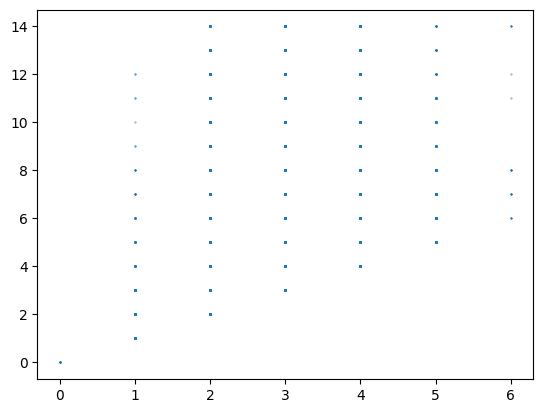

In [89]:
plt.scatter(X_click, y_click, s=0.1)

In [90]:
X_llm = [get_optimal_llm_length(p) for p in tqdm(dataloader.paths["path"])]
y_llm = [get_semantic_path_length(p) for p in tqdm(dataloader.paths["path"])]

100%|██████████| 49620/49620 [00:02<00:00, 18153.95it/s]


In [91]:
slope, intercept, r_value, p_value, std_err = stats.linregress(X_llm, y_llm)
print(f"LLM correlation: {r_value} (p={p_value})")

LLM correlation: 0.47146549642627916 (p=0.0)


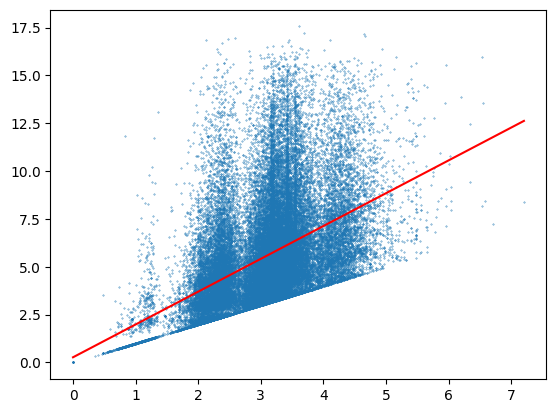

In [92]:
plt.scatter(X_llm, y_llm, s=0.1)
xmin = min(X_llm)
xmax = max(X_llm)
xs = np.linspace(xmin, xmax, 100)
ys = slope * xs + intercept
plt.plot(xs, ys, color='red')

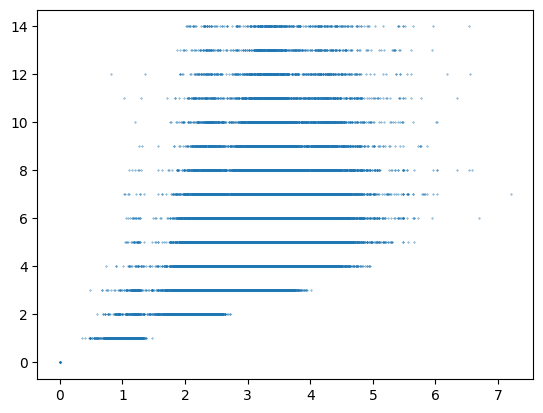

In [93]:
plt.scatter(X_llm, y_click, s=0.1)

In [96]:
num_optimal_llm = sum(1 for x,y in zip(X_llm, y_llm) if abs(x - y) < 0.001)
num_optimal_click = sum(1 for x,y in zip(X_click, y_click) if abs(x - y) < 0.001)
print(f"LLM optimal: {num_optimal_llm} / {len(y_llm)} ({num_optimal_llm / len(y_llm):.2%})")
print(f"Click optimal: {num_optimal_click} / {len(y_click)} ({num_optimal_click / len(y_click):.2%})")

LLM optimal: 5241 / 49620 (10.56%)
Click optimal: 10257 / 49620 (20.67%)
